In [1]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# =========================================
# LOAD DATASET
# =========================================

housing = fetch_california_housing(as_frame=True)

df = pd.concat(
    [housing.data, housing.target.rename("HousePrice")],
    axis=1
)

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(20640, 9)

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


In [3]:
# =========================================
# CHECK MISSING VALUES
# =========================================

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


In [4]:
# =========================================
# BASIC INFORMATION
# =========================================

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.84

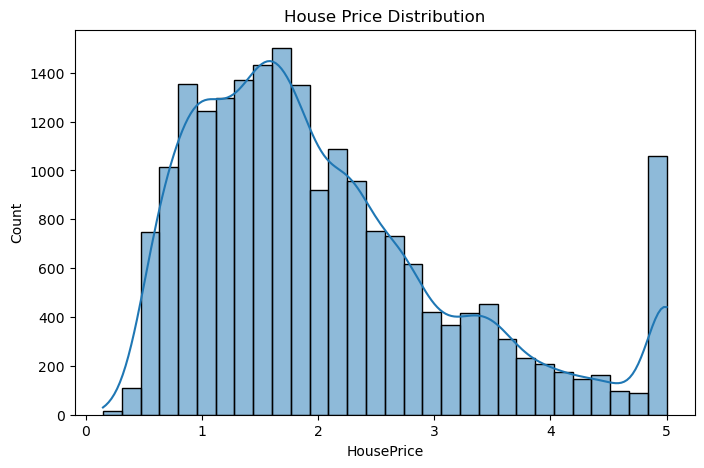

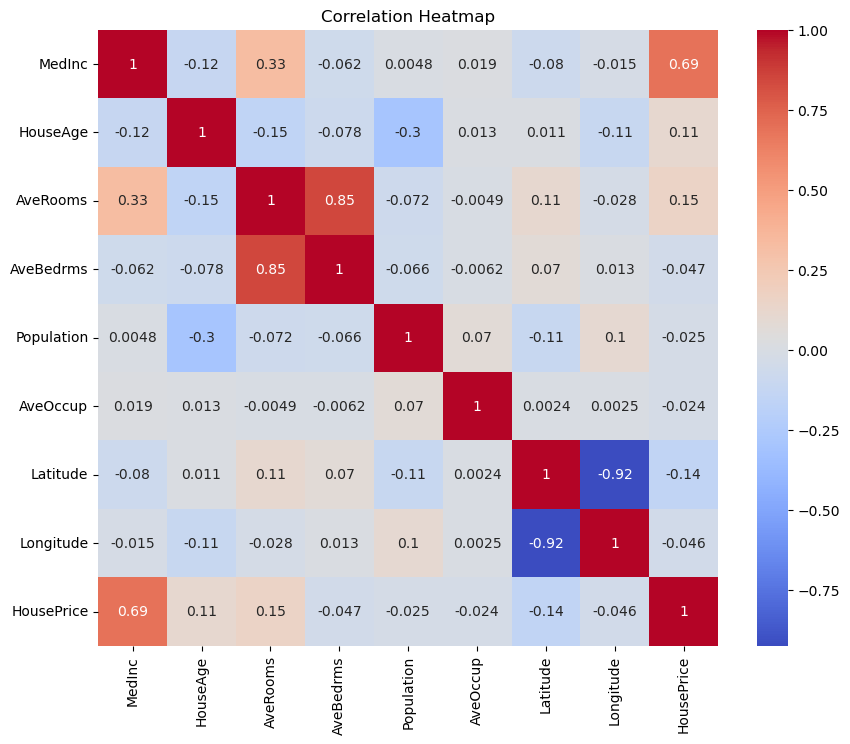

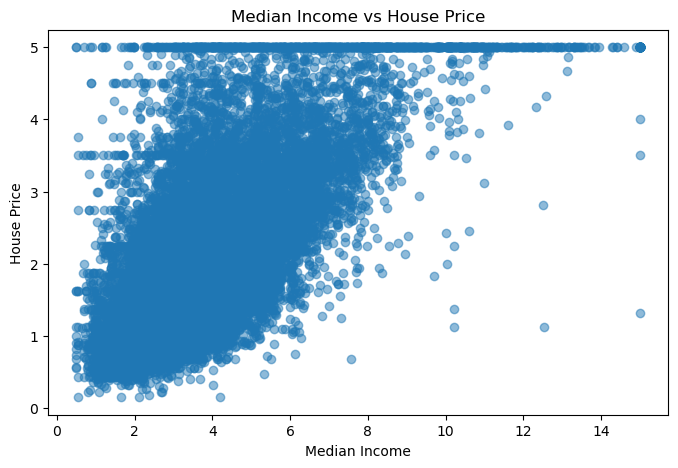

In [5]:
# =========================================
# DATA VISUALIZATION (EDA)
# =========================================

# Distribution of target variable
plt.figure(figsize=(8,5))
sns.histplot(df["HousePrice"], bins=30, kde=True)
plt.title("House Price Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df["MedInc"], df["HousePrice"], alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")
plt.show()

In [6]:
# =========================================
# SELECT FEATURES AND TARGET
# =========================================

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [7]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [8]:
# =========================================
# TRAIN MODEL
# =========================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [9]:
# =========================================
# PREDICTIONS
# =========================================

y_pred = model.predict(X_test)

In [10]:
# =========================================
# MODEL EVALUATION
# =========================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("------------------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 3))


Model Performance
------------------------
MAE : 0.533
RMSE: 0.746
R2 Score: 0.576


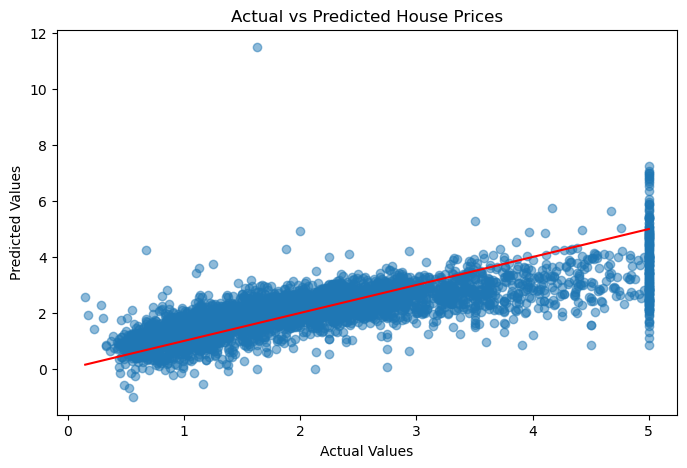

In [11]:
# =========================================
# ACTUAL VS PREDICTED GRAPH
# =========================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

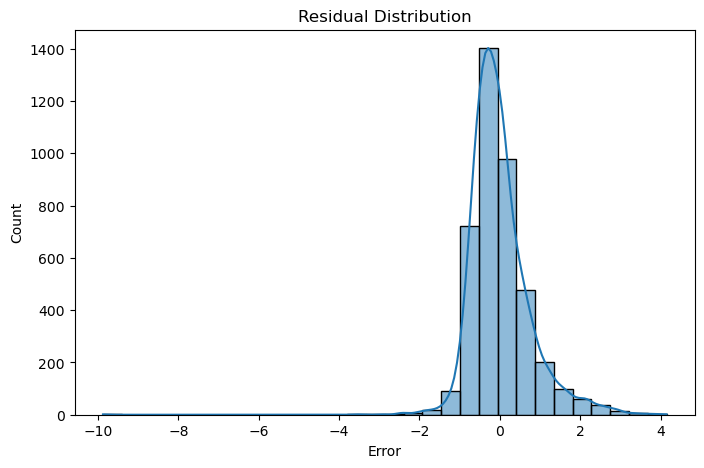

In [12]:
# =========================================
# RESIDUALS PLOT
# =========================================

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Error")

plt.show()

In [13]:
# =========================================
# SAVE MODEL
# =========================================

joblib.dump(model, "house_price_model.pkl")

print("\nModel saved as house_price_model.pkl")


Model saved as house_price_model.pkl


In [16]:
import joblib
import pandas as pd

model = joblib.load("house_price_model.pkl")

print("California House Price Prediction")
print("----------------------------------")

MedInc = float(input("Median Income: "))
HouseAge = float(input("House Age: "))
AveRooms = float(input("Average Rooms: "))
AveBedrms = float(input("Average Bedrooms: "))
Population = float(input("Population: "))
AveOccup = float(input("Average Occupancy: "))
Latitude = float(input("Latitude: "))
Longitude = float(input("Longitude: "))

features = pd.DataFrame([{
    "MedInc": MedInc,
    "HouseAge": HouseAge,
    "AveRooms": AveRooms,
    "AveBedrms": AveBedrms,
    "Population": Population,
    "AveOccup": AveOccup,
    "Latitude": Latitude,
    "Longitude": Longitude
}])

prediction = model.predict(features)

print("\nPredicted House Price:", round(prediction[0], 3))

California House Price Prediction
----------------------------------


Median Income:  4.5
House Age:  20
Average Rooms:  5
Average Bedrooms:  1
Population:  800
Average Occupancy:  3
Latitude:  34.2
Longitude:  -118.3



Predicted House Price: 2.295
